In [1]:
from qiskit.synthesis import TwoQubitWeylDecomposition

In [2]:
from qiskit.circuit.library import UnitaryGate
import numpy as np

In [3]:
dim = 4
X = np.random.randn(2**dim, 2**dim) + 1j * np.random.randn(2**dim, 2**dim)
Q, R = np.linalg.qr(X)

D = np.diag(R)
U = Q @ np.diag(D / np.abs(D))
U

array([[-3.05130278e-01+0.03230049j,  1.74513783e-01-0.14817504j,
        -4.02048379e-01-0.01134268j, -1.54100717e-01+0.15974456j,
         1.82857953e-01-0.10048852j,  5.07180511e-02-0.19419979j,
         7.12239454e-02+0.05414152j, -1.02892590e-01+0.01097551j,
         1.84080524e-01-0.2070728j ,  3.00648113e-01+0.10604166j,
         2.37883195e-01+0.18166972j,  3.17471239e-01-0.08688628j,
         1.47153630e-02+0.0369537j , -1.31269966e-01-0.01073934j,
         1.86682544e-01+0.23094702j,  2.15884668e-01+0.09910228j],
       [ 4.87792628e-02+0.29225387j, -9.37893009e-02-0.18091645j,
         1.16544866e-01-0.01008309j, -4.61755607e-02+0.05526911j,
         8.28656284e-02+0.1096279j ,  1.63584009e-01-0.0919207j ,
        -1.22621434e-01+0.45525648j,  2.14695141e-01+0.13691281j,
        -6.94841279e-02+0.26809624j, -6.57108131e-02-0.22396063j,
         9.75186257e-03+0.21013178j,  1.33973460e-01-0.27383003j,
         9.05452017e-02-0.19123238j,  2.68451608e-02-0.40866448j,
        -

In [4]:
from qiskit.synthesis import qs_decomposition

In [5]:
qs_decomposition(U).depth()

189

In [6]:
from qiskit import QuantumCircuit

In [7]:
UnitaryGate(U)

Instruction(name='unitary', num_qubits=4, num_clbits=0, params=[array([[-3.05130278e-01+0.03230049j,  1.74513783e-01-0.14817504j,
        -4.02048379e-01-0.01134268j, -1.54100717e-01+0.15974456j,
         1.82857953e-01-0.10048852j,  5.07180511e-02-0.19419979j,
         7.12239454e-02+0.05414152j, -1.02892590e-01+0.01097551j,
         1.84080524e-01-0.2070728j ,  3.00648113e-01+0.10604166j,
         2.37883195e-01+0.18166972j,  3.17471239e-01-0.08688628j,
         1.47153630e-02+0.0369537j , -1.31269966e-01-0.01073934j,
         1.86682544e-01+0.23094702j,  2.15884668e-01+0.09910228j],
       [ 4.87792628e-02+0.29225387j, -9.37893009e-02-0.18091645j,
         1.16544866e-01-0.01008309j, -4.61755607e-02+0.05526911j,
         8.28656284e-02+0.1096279j ,  1.63584009e-01-0.0919207j ,
        -1.22621434e-01+0.45525648j,  2.14695141e-01+0.13691281j,
        -6.94841279e-02+0.26809624j, -6.57108131e-02-0.22396063j,
         9.75186257e-03+0.21013178j,  1.33973460e-01-0.27383003j,
         9.

In [8]:
qc = QuantumCircuit(4)
qc.append(UnitaryGate(U), [0, 1, 2, 3])

qc.decompose().depth()

189

In [32]:
BASIS_GATES = ["cz", "id", "rx", "rz", "rzz", "sx", "x"]

COUPLING_MAP = [
    # poziome
    [0,1],[1,2],[2,3],[3,4],[4,5],[5,6],[6,7],[7,8],[8,9],[9,10],[10,11],[11,12],[12,13],[13,14],[14,15],
    [16,17],[17,18],[18,19],[19,20],[20,21],[21,22],[22,23],[23,24],[24,25],[25,26],[26,27],[27,28],[28,29],[29,30],[30,31],
    [32,33],[33,34],[34,35],[35,36],[36,37],[37,38],[38,39],[39,40],[40,41],[41,42],[42,43],[43,44],[44,45],[45,46],[46,47],
    [48,49],[49,50],[50,51],[51,52],[52,53],[53,54],[54,55],[55,56],[56,57],[57,58],[58,59],[59,60],[60,61],[61,62],[62,63],
    [64,65],[65,66],[66,67],[67,68],[68,69],[69,70],[70,71],[71,72],[72,73],[73,74],[74,75],[75,76],[76,77],[77,78],[78,79],
    [80,81],[81,82],[82,83],[83,84],[84,85],[85,86],[86,87],[87,88],[88,89],[89,90],[90,91],[91,92],[92,93],[93,94],[94,95],
    [96,97],[97,98],[98,99],[99,100],[100,101],[101,102],[102,103],[103,104],[104,105],[105,106],[106,107],[107,108],[108,109],[109,110],[110,111],
    [112,113],[113,114],[114,115],[115,116],[116,117],[117,118],[118,119],[119,120],[120,121],[121,122],[122,123],[123,124],[124,125],[125,126],[126,127],
    # pionowe
    [3,19],[7,23],[11,27],[15,31],
    [17,33],[21,37],[25,41],[29,45],
    [35,51],[39,55],[43,59],[47,63],
    [49,65],[53,69],[57,73],[61,77],
    [67,83],[71,87],[75,91],[79,95],
    [81,97],[85,101],[89,105],[93,109],
    [99,115],[103,119],[107,123],[111,127],
]

from qiskit import transpile

In [10]:
qctr = transpile(qc,
                 basis_gates=BASIS_GATES,
                 coupling_map=COUPLING_MAP,
                 optimization_level=3)

In [11]:
qctr.depth()

513

In [12]:
from qiskit.transpiler.preset_passmanagers.plugin import list_stage_plugins

In [13]:
list_stage_plugins("optimization")

['default']

In [14]:
from qiskit.transpiler import generate_preset_pass_manager

In [33]:

pm_max = generate_preset_pass_manager(basis_gates=BASIS_GATES, optimization_level=3)

In [16]:
from qiskit import qpy

In [17]:
with open("C:/Users/szymo/QuditsOnQubits/QuditsOnQubits/data/benchmarks/circuits/fourier_like/D110_F3_D111.qpy", "rb") as fd:
        benchqc = qpy.load(fd)[0]

In [18]:
qctest = pm.run(benchqc)
qcmax = pm_max.run(benchqc)

NameError: name 'pm' is not defined

In [ ]:
qctest.depth(), qcmax.depth()

(0, 42)

#TODO zrobic tak ze badac pare poziomow fidelity np 85, 90 i 95, i dla kazdego tego poziomu zbadac jak najnizszy approximation_degree w transpilatorze

In [19]:
from qiskit.quantum_info import state_fidelity, DensityMatrix, Operator, Statevector


In [20]:
qctest.draw("mpl")

NameError: name 'qctest' is not defined

In [ ]:
state_fidelity(DensityMatrix(qctest), DensityMatrix(qcmax))

0.03703703703704005

In [ ]:
def fid_check(qc, qcmax):
    for i in range(10):
        pm = generate_preset_pass_manager(basis_gates=BASIS_GATES, optimization_level=3, approximation_degree=(i/100 + 0.9))
        qctest = pm.run(qc)
        print(f"arpox = {i/100 + 0.9}\nFid: {state_fidelity(DensityMatrix(qctest), DensityMatrix(qcmax))} \nDepth: {qctest.depth()}")

In [ ]:
with open("C:/Users/szymo/QuditsOnQubits/QuditsOnQubits/data/benchmarks/circuits/baseline/E_old.qpy", "rb") as fd:
        baseqc = qpy.load(fd)[0]

In [ ]:
qcbasemax = pm_max.run(baseqc)

In [ ]:
qcbasemax.depth()

22

In [ ]:
fid_check(baseqc, qcbasemax)

arpox = 0.9
Fid: 0.4451373773423677 
Depth: 19
arpox = 0.91
Fid: 0.878589832701324 
Depth: 19
arpox = 0.92
Fid: 0.878589832701324 
Depth: 19
arpox = 0.93
Fid: 0.878589832701324 
Depth: 19
arpox = 0.9400000000000001
Fid: 0.878589832701324 
Depth: 19
arpox = 0.9500000000000001
Fid: 0.9097895524833622 
Depth: 19
arpox = 0.96
Fid: 0.9097895524833622 
Depth: 19
arpox = 0.97
Fid: 0.9097895524833622 
Depth: 19
arpox = 0.98
Fid: 0.9097895524833622 
Depth: 19
arpox = 0.99
Fid: 0.9908612100649324 
Depth: 19


In [ ]:
from igraph import Graph, plot
import matplotlib.pyplot as plt

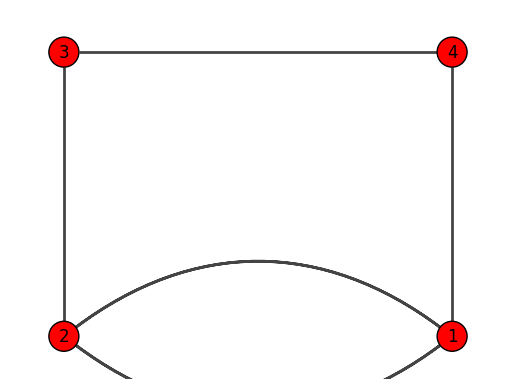

In [ ]:
game43 = Graph(n=4, edges=[[0, 1], [0, 1],  [1, 2], [2, 3], [3, 0]])
game43.vs["name"] = [i+1 for i in range(game43.vcount())]
fig, ax = plt.subplots()
plot(game43, target=ax, vertex_label=game43.vs["name"])

In [ ]:
from qiskit.circuit.library import StatePreparation

In [ ]:
X[0]

array([-0.23176132+0.41513042j, -0.256383  +0.03687824j,
        0.15265034+0.682613j  , -0.88531334+1.14537284j,
        1.12584793-0.21856744j,  0.23221331+1.17482147j,
        2.03019774-0.71632577j, -0.94976221-0.77111112j,
        0.25631397+0.32561151j, -0.5066449 +0.96909109j,
        0.66156927-0.31301271j,  0.19017577-1.22929041j,
       -1.28896735-2.36111765j, -1.16125018-0.99633441j,
       -0.52927502-0.51983422j,  0.17984257+0.27556036j])

In [ ]:
dim = 2
X = np.random.randn(2**dim, 1)

In [ ]:
np.sum(X)

np.float64(-1.5825267154553133)

In [ ]:
np.linalg.norm(X)

np.float64(2.0644777251787927)

In [ ]:
np.norm

In [ ]:
X / np.linalg.norm(X)

array([[-0.61843621],
       [-0.37697104],
       [-0.35951358],
       [ 0.58837019]])

In [ ]:
svX = Statevector(X / np.linalg.norm(X))

In [ ]:
testSP = StatePreparation(svX)

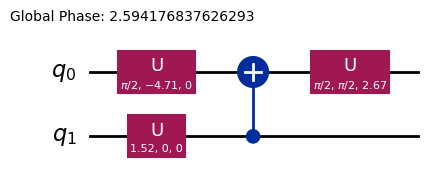

In [ ]:
qc = QuantumCircuit(2)
qc.append(testSP, [0,1])
qc.decompose().decompose().decompose().decompose().draw("mpl")

In [ ]:
with open("C:/Users/szymo/QuditsOnQubits/QuditsOnQubits/data/benchmarks/circuits/two_qutrit/monomial/P012_ph101.qpy", "rb") as fd:
        monomial = qpy.load(fd)[0]

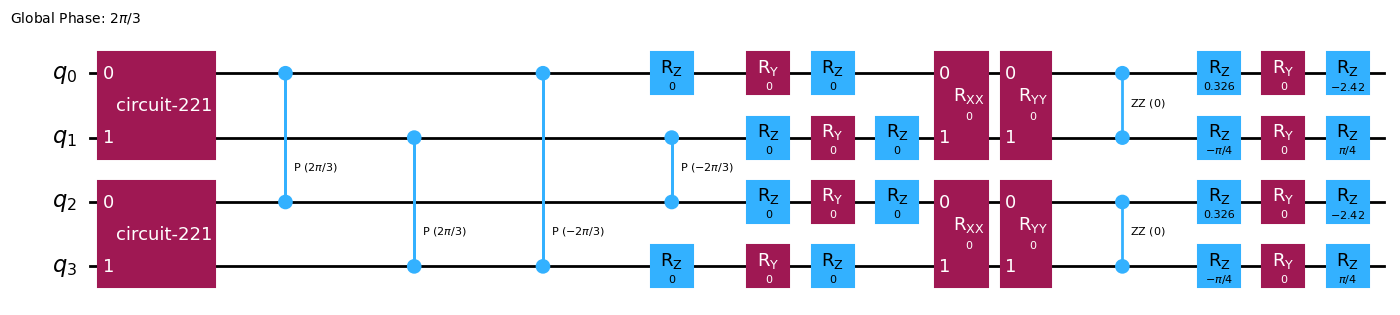

In [ ]:
monomial.decompose().draw("mpl")

In [ ]:
with open("C:/Users/szymo/QuditsOnQubits/QuditsOnQubits/data/benchmarks/circuits/two_qutrit/baseline/E_old.qpy", "rb") as fd:
        baseline = qpy.load(fd)[0]

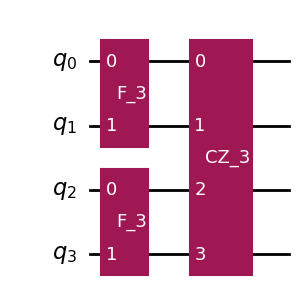

In [ ]:
baseline.draw("mpl")

In [ ]:
QuditsOnQubits\data\benchmarks\circuits\ame43\monomial_full\sup012_P012_ph220__transpiled_1.qpy

In [40]:
with open("C:/Users/szymo/QuditsOnQubits/QuditsOnQubits/data/benchmarks/circuits/ame43/monomial_full/sup012_P012_ph220__transpiled_1.qpy", "rb") as fd:
        ame43 = qpy.load(fd)[0]

In [43]:
with open("C:/Users/szymo/QuditsOnQubits/QuditsOnQubits/data/benchmarks/circuits/ame43/monomial_full/sup012_P012_ph220__W.qpy", "rb") as fd:
        W = qpy.load(fd)[0]

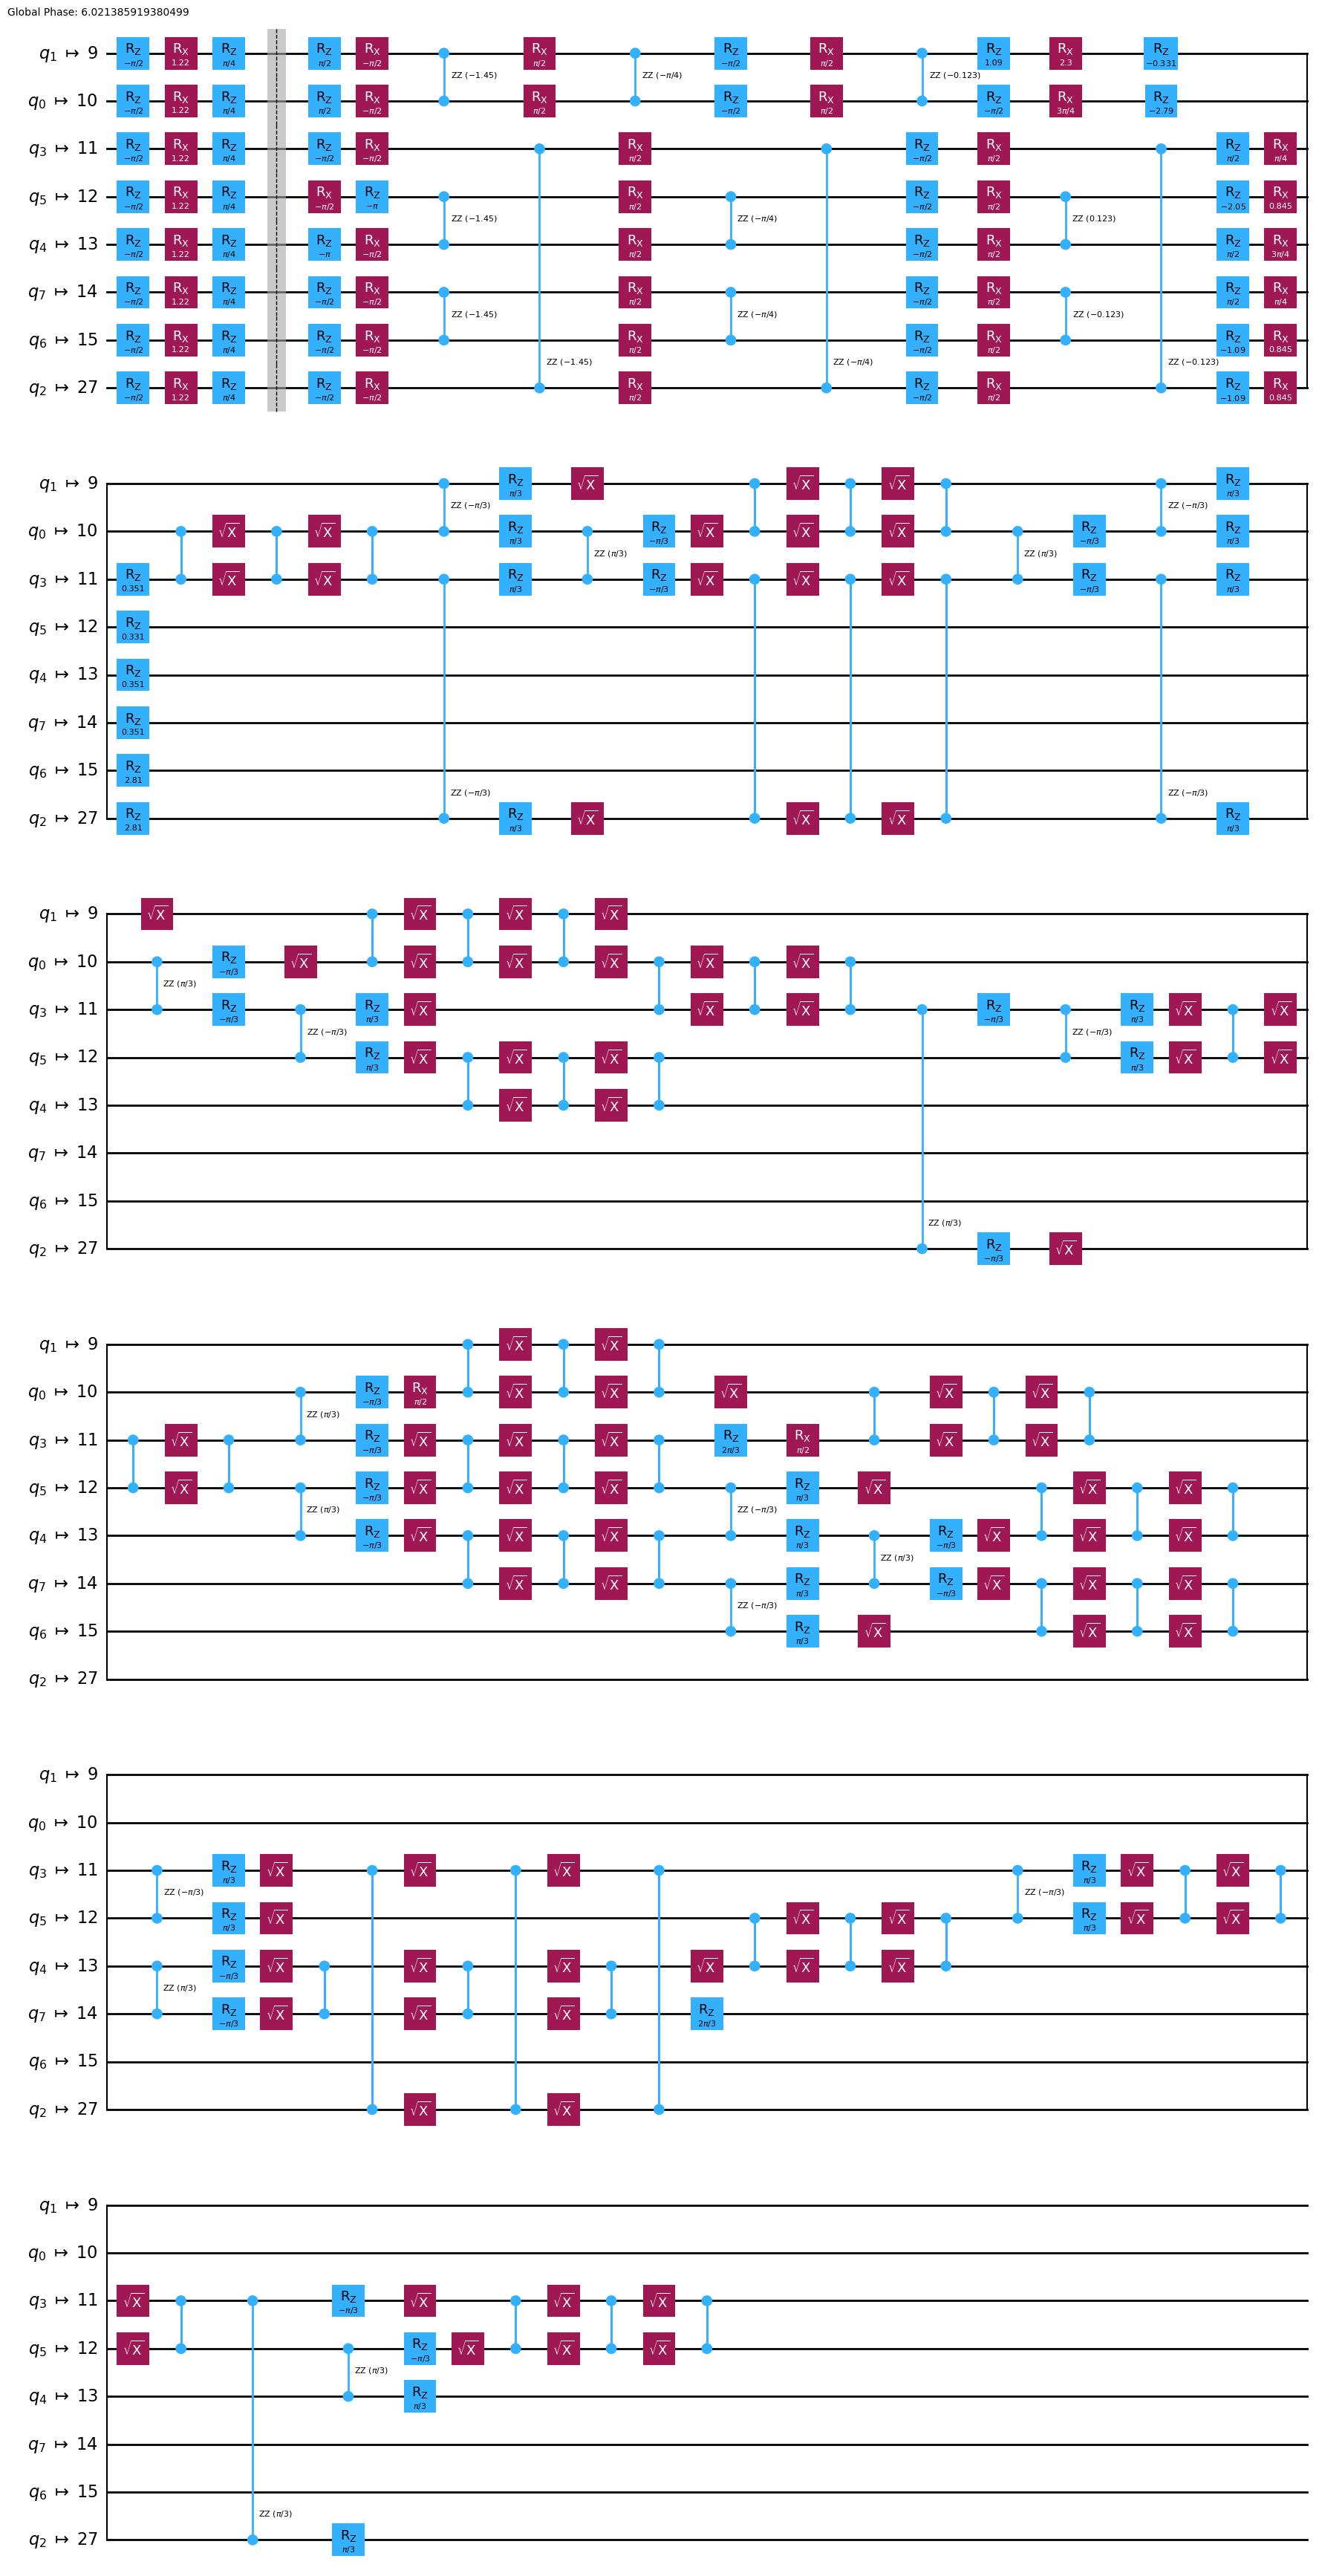

In [41]:
ame43.draw("mpl")

In [42]:
ame43.depth()

105

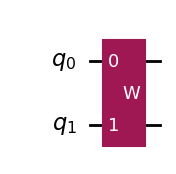

In [44]:
W.draw("mpl")

In [46]:
Operator(W).draw("latex")

<IPython.core.display.Latex object>

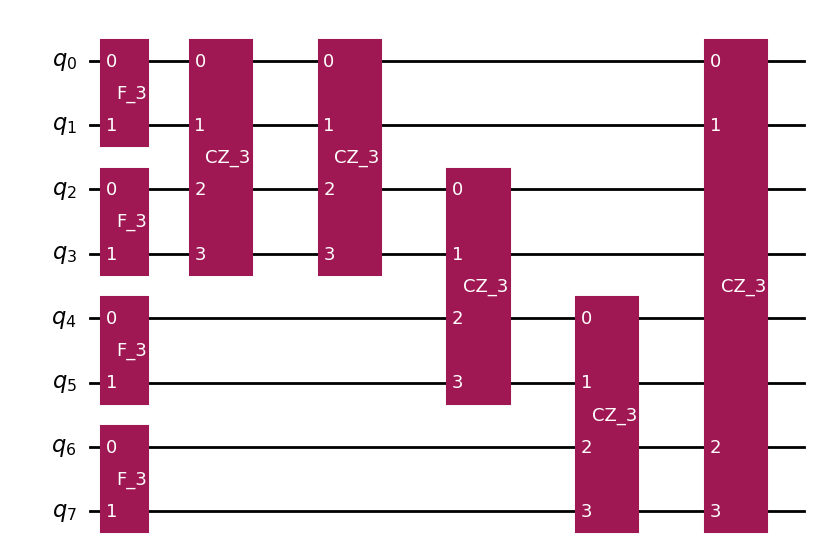

In [30]:
ame43old.draw("mpl")

In [23]:
pm

NameError: name 'pm' is not defined

In [26]:
qctrans = pm_max.run(ame43)

In [27]:
qctrans.depth()

34

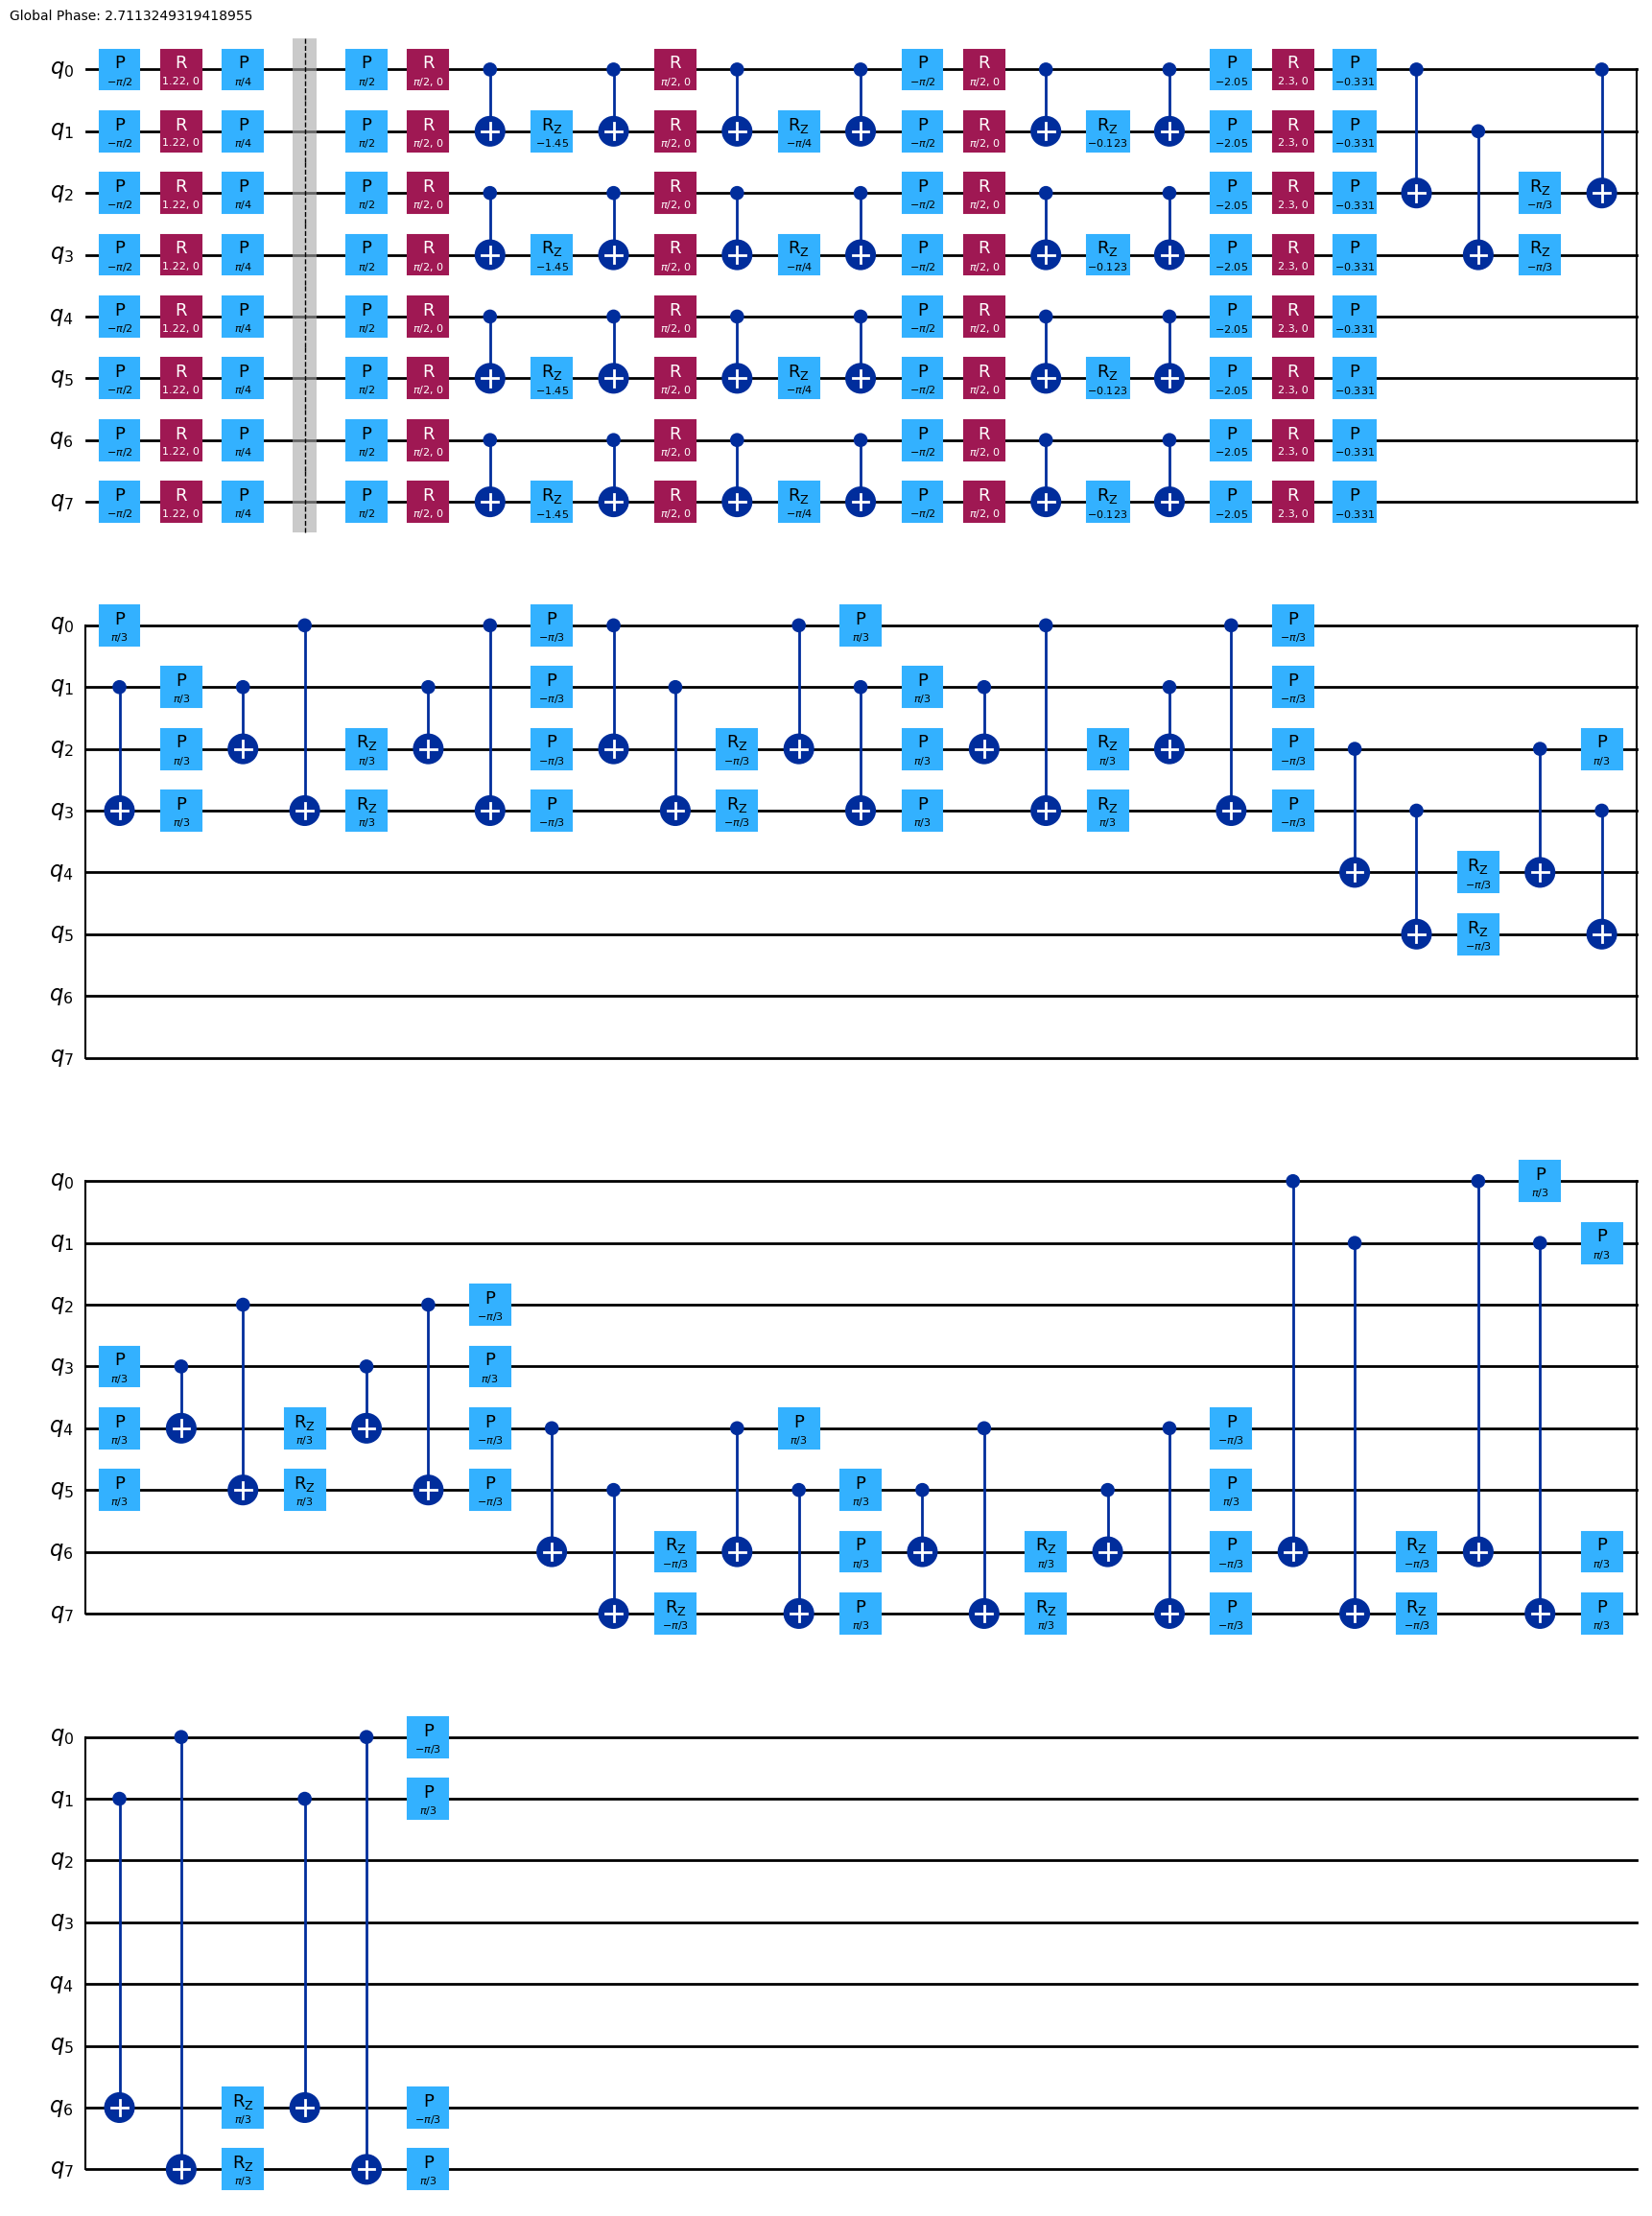

In [28]:
qctrans.decompose().draw("mpl")

In [31]:
qcold = pm_max.run(ame43old)
qcold.depth()


34

In [34]:
pm_ref = generate_preset_pass_manager(
        basis_gates=BASIS_GATES,
        optimization_level=3
    )

In [35]:
qcame432 = pm_ref.run(ame43)
qcame432.depth()

34

In [36]:
qcame432 = pm_ref.run(ame43old)
qcame432.depth()

34

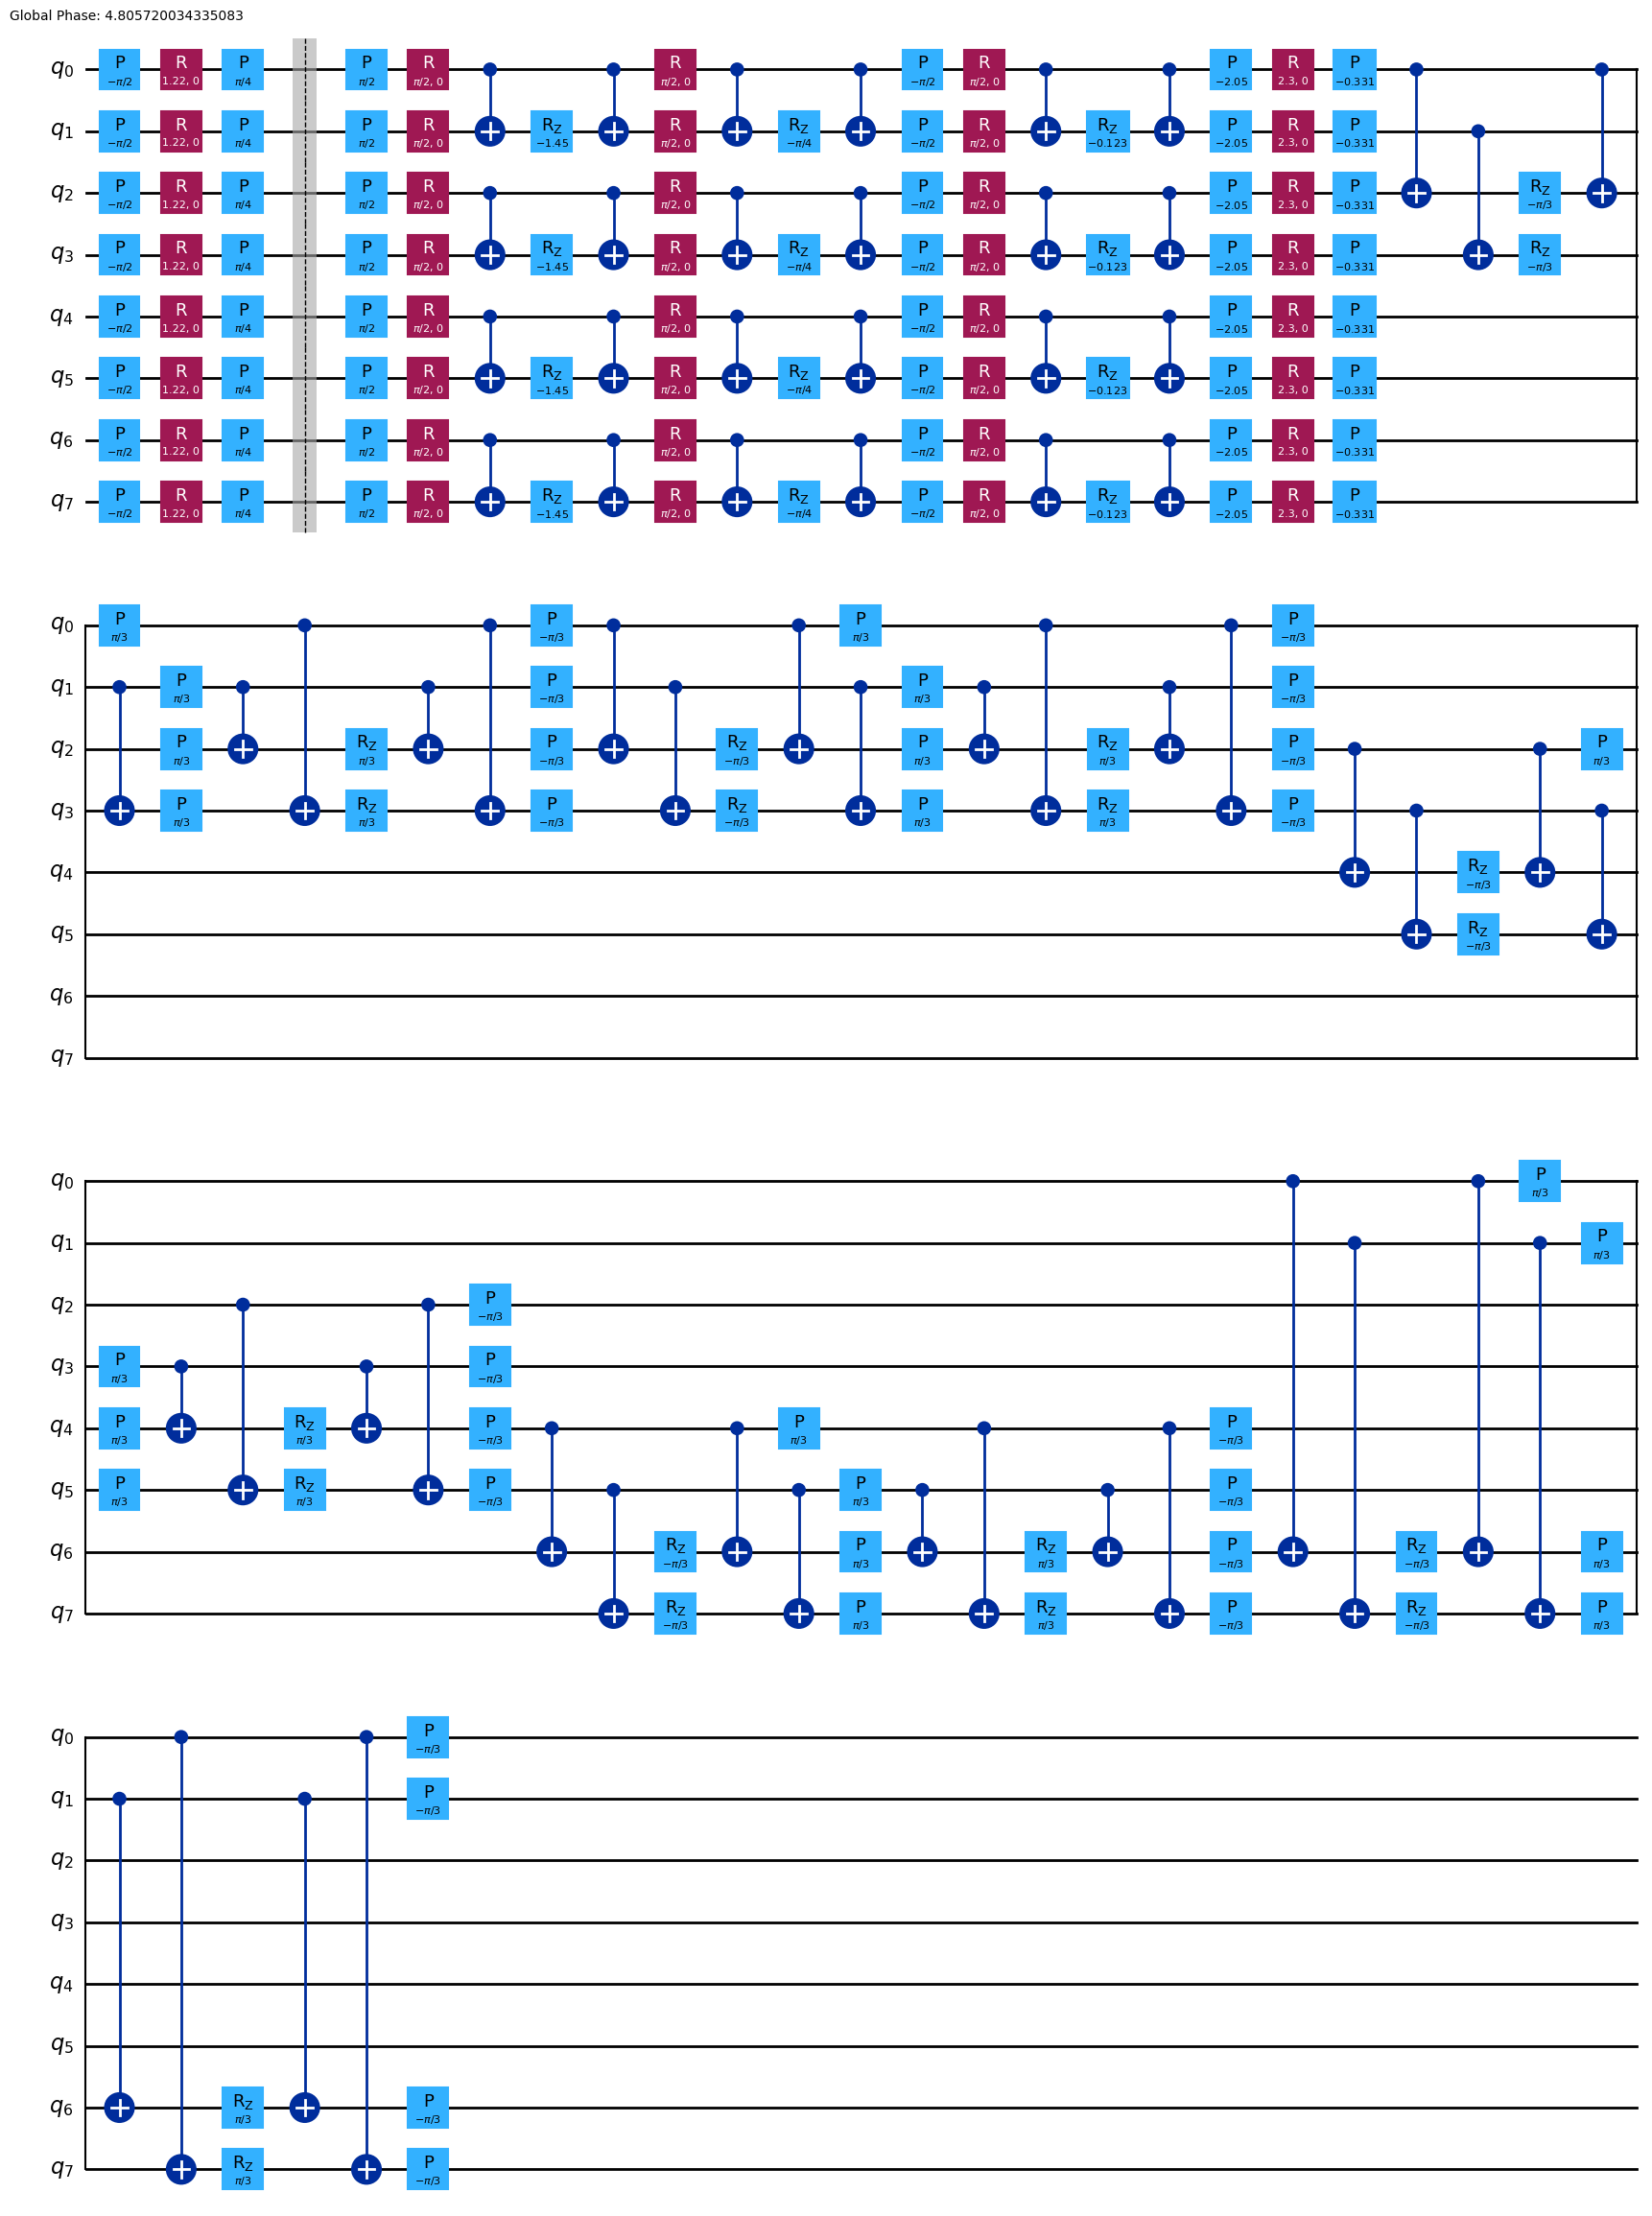

In [37]:
qcame432.decompose().draw("mpl")